In [1]:
# The AMEX dataset has dates but no confirmed underwriting-policy indicator.
# We therefore detect structural changes first and treat them as
# candidate regime shifts rather than automatically calling them causal.

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from sqlalchemy import create_engine
from dotenv import load_dotenv

import statsmodels.formula.api as smf


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


load_dotenv(
    PROJECT_ROOT / ".env"
)


engine = create_engine(
    f"postgresql+psycopg2://"
    f"{os.getenv('DB_USER', 'ahadke')}:"
    f"{os.getenv('DB_PASSWORD', '')}@"
    f"{os.getenv('DB_HOST', 'localhost')}:"
    f"{os.getenv('DB_PORT', '5432')}/"
    f"{os.getenv('DB_NAME', 'amex_credit_risk')}"
)


PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


In [2]:
customers = pd.read_sql(
    """
    SELECT *
    FROM dim_customer
    """,
    engine,
)


customers[
    "last_statement_date"
] = pd.to_datetime(
    customers[
        "last_statement_date"
    ]
)


customers[
    "first_statement_date"
] = pd.to_datetime(
    customers[
        "first_statement_date"
    ]
)


# Preferred clock is the final-statement cohort.
# In this AMEX train extract every customer ends in 2018-03,
# so that clock has no time variation and cannot support ITS.
last_months = (
    customers[
        "last_statement_date"
    ]
    .dt.to_period("M")
    .nunique()
)

if last_months >= 7:
    cohort_source = "last_statement_date"
    cohort_note = "final statement cohort"
else:
    cohort_source = "first_statement_date"
    cohort_note = (
        "first-statement cohort fallback; "
        "last-statement cohort is a single month"
    )

customers[
    "cohort_month"
] = (
    customers[
        cohort_source
    ]
    .dt.to_period(
        "M"
    )
    .dt.to_timestamp()
)


print(
    "Cohort clock:",
    cohort_note,
)

print(
    "Distinct cohort months:",
    customers["cohort_month"].nunique(),
)


Cohort clock: first-statement cohort fallback; last-statement cohort is a single month
Distinct cohort months: 13


In [3]:
monthly = (
    customers
    .groupby(
        "cohort_month",
        as_index=False,
    )
    .agg(
        customers=(
            "customer_ID",
            "count",
        ),
        default_rate=(
            "target",
            "mean",
        ),
        mean_statement_count=(
            "n_statements",
            "mean",
        ),
    )
    .sort_values(
        "cohort_month"
    )
    .reset_index(drop=True)
)


monthly

,cohort_month,customers,default_rate,mean_statement_count
0,2017-03-01,395630,0.232017,12.940702
1,2017-04-01,6911,0.481262,11.498047
2,2017-05-01,3945,0.498859,10.737389
3,2017-06-01,6040,0.486921,9.856457
4,2017-07-01,5787,0.474339,8.938137
5,2017-08-01,5624,0.467994,7.958570
6,2017-09-01,4423,0.454217,6.974226
7,2017-10-01,4848,0.417698,5.981642
8,2017-11-01,4554,0.406675,4.938516
9,2017-12-01,4616,0.422010,3.944541


In [4]:
# Composition control: median of top shortlisted features by cohort.
# If customer mix changes around a break, a default-rate shift
# may reflect who is in the sample rather than a policy treatment.

shortlist = pd.read_csv(
    PROCESSED_DIR / "statistical_shortlist.csv"
)

composition_features = (
    shortlist["feature"]
    .head(5)
    .tolist()
)

latest = pd.read_parquet(
    PROCESSED_DIR / "customer_feature_sample.parquet"
)

keep_cols = [
    column
    for column in ["customer_ID"] + composition_features
    if column in latest.columns
]

merged = customers.merge(
    latest[keep_cols],
    on="customer_ID",
    how="left",
)

composition = (
    merged
    .groupby("cohort_month", as_index=False)[composition_features]
    .median()
)

monthly = monthly.merge(
    composition,
    on="cohort_month",
    how="left",
)

print(
    "Composition features:",
    composition_features,
)

monthly[
    ["cohort_month", "customers", "default_rate"]
    + composition_features
]


Composition features: ['P_2', 'D_44', 'B_2', 'B_1', 'B_9']


,cohort_month,customers,default_rate,P_2,D_44,B_2,B_1,B_9
0,2017-03-01,395630,0.232017,0.717446,0.007784,0.814022,0.030098,0.018766
1,2017-04-01,6911,0.481262,0.426305,0.129632,0.166429,0.082109,0.340351
2,2017-05-01,3945,0.498859,0.420249,0.129700,0.139399,0.092110,0.444533
3,2017-06-01,6040,0.486921,0.425883,0.129407,0.166501,0.083077,0.387633
4,2017-07-01,5787,0.474339,0.443819,0.128069,0.198748,0.073550,0.348887
5,2017-08-01,5624,0.467994,0.444600,0.127733,0.199756,0.076039,0.330124
6,2017-09-01,4423,0.454217,0.469067,0.125742,0.261909,0.064656,0.288348
7,2017-10-01,4848,0.417698,0.486216,0.009655,0.447253,0.053909,0.217150
8,2017-11-01,4554,0.406675,0.501285,0.009267,0.630603,0.053271,0.194582
9,2017-12-01,4616,0.422010,0.493532,0.009277,0.650175,0.058575,0.202392


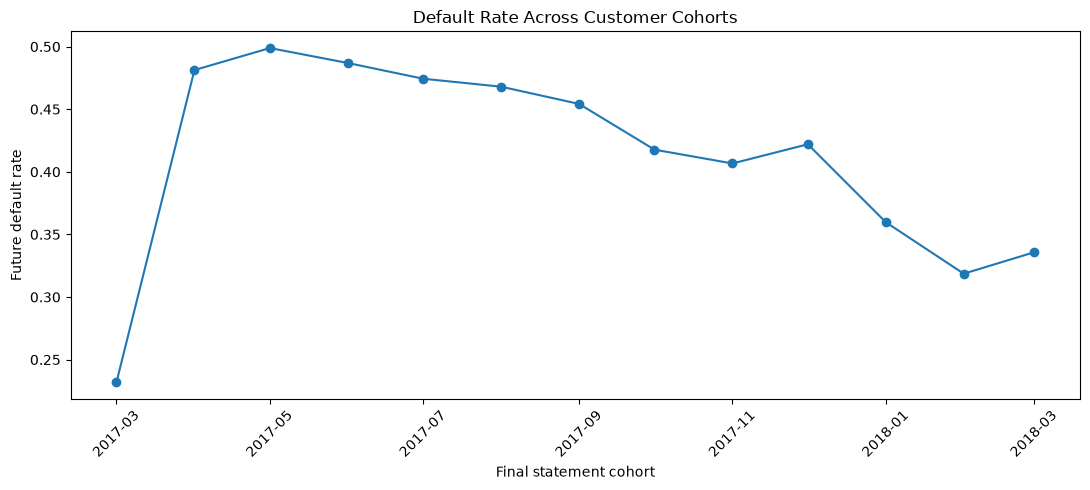

In [5]:
plt.figure(
    figsize=(11, 5)
)

plt.plot(
    monthly[
        "cohort_month"
    ],
    monthly[
        "default_rate"
    ],
    marker="o",
)

plt.xlabel(
    "Final statement cohort"
)

plt.ylabel(
    "Future default rate"
)

plt.title(
    "Default Rate Across Customer Cohorts"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

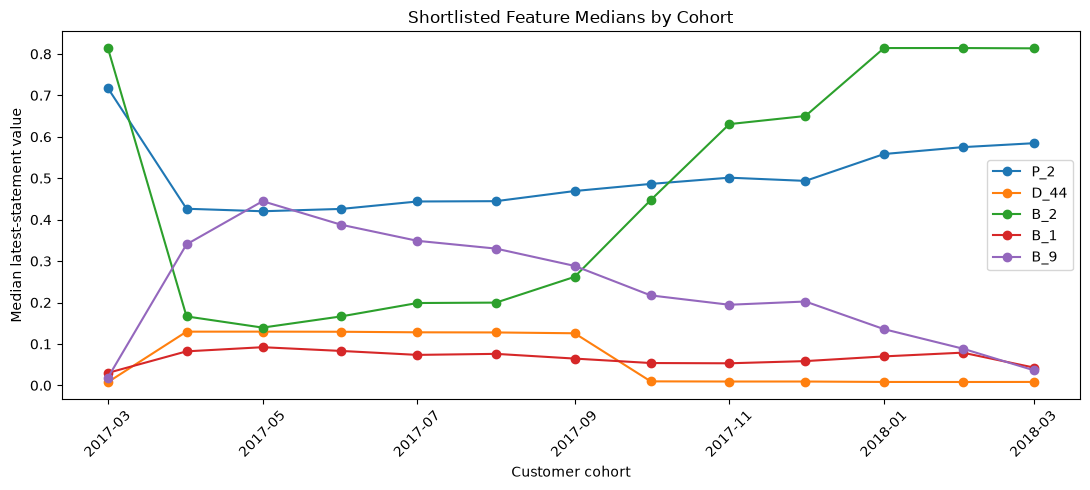

In [6]:
plt.figure(figsize=(11, 5))

for feature in composition_features:
    plt.plot(
        monthly["cohort_month"],
        monthly[feature],
        marker="o",
        label=feature,
    )

plt.xlabel("Customer cohort")
plt.ylabel("Median latest-statement value")
plt.title("Shortlisted Feature Medians by Cohort")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [7]:
# We evaluate possible breakpoints systematically
# rather than choosing whichever date looks convenient.

def fit_break_model(
    data,
    break_index,
):

    temp = data.copy()

    temp[
        "time"
    ] = np.arange(
        len(temp)
    )

    temp[
        "post"
    ] = (
        temp[
            "time"
        ] >= break_index
    ).astype(int)

    temp[
        "time_after"
    ] = (
        temp[
            "time"
        ]
        - break_index
    ).clip(
        lower=0
    )

    model = smf.ols(
        """
        default_rate
        ~ time
        + post
        + time_after
        """,
        data=temp,
    ).fit()

    return model

In [8]:
break_results = []


for break_index in range(
    3,
    len(monthly) - 3,
):

    model = fit_break_model(
        monthly,
        break_index,
    )

    break_results.append(
        {
            "break_index":
                break_index,

            "break_month":
                monthly.loc[
                    break_index,
                    "cohort_month",
                ],

            "ssr":
                np.sum(
                    model.resid ** 2
                ),

            "aic":
                model.aic,
        }
    )


break_results = (
    pd.DataFrame(
        break_results
    )
    .sort_values(
        "ssr"
    )
)


break_results.head()

,break_index,break_month,ssr,aic
0,3,2017-06-01,0.011616,-46.371327
1,4,2017-07-01,0.021549,-38.338243
2,5,2017-08-01,0.029877,-34.090768
3,6,2017-09-01,0.036023,-31.658873
4,7,2017-10-01,0.041451,-29.834222


In [9]:
best_break_index = int(
    break_results.iloc[
        0
    ][
        "break_index"
    ]
)


candidate_break = monthly.loc[
    best_break_index,
    "cohort_month",
]


print(
    "Candidate structural break:",
    candidate_break,
)

print(
    "This is not automatically a confirmed policy-change date."
)

Candidate structural break: 2017-06-01 00:00:00
This is not automatically a confirmed policy-change date.


In [10]:
monthly[
    "time"
] = np.arange(
    len(monthly)
)


monthly[
    "post"
] = (
    monthly[
        "time"
    ] >= best_break_index
).astype(int)


monthly[
    "time_after"
] = (
    monthly[
        "time"
    ]
    - best_break_index
).clip(
    lower=0
)

In [11]:
# Interrupted time-series regression estimates
# the pre-break trend, immediate level shift,
# and trend change after the candidate breakpoint.

its_model = smf.ols(
    """
    default_rate
    ~ time
    + post
    + time_after
    """,
    data=monthly,
).fit(
    cov_type="HAC",
    cov_kwds={
        "maxlags": 1
    },
)


print(
    its_model.summary()
)

                            OLS Regression Results                            
Dep. Variable:           default_rate   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     52.35
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           5.08e-06
Time:                        19:54:14   Log-Likelihood:                 27.186
No. Observations:                  13   AIC:                            -46.37
Df Residuals:                       9   BIC:                            -44.11
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2706      0.033      8.248      0.0

In [12]:
# These checks make the causal limitation explicit.
# The dataset does not supply everything required for a true DiD or RDD.

identification_check = pd.DataFrame(
    [
        {
            "requirement":
                "Known policy treatment indicator",
            "available":
                False,
        },
        {
            "requirement":
                "Known external policy-change date",
            "available":
                False,
        },
        {
            "requirement":
                "Untreated control group",
            "available":
                False,
        },
        {
            "requirement":
                "RDD assignment variable",
            "available":
                False,
        },
        {
            "requirement":
                "Temporal customer cohorts",
            "available":
                True,
        },
    ]
)


identification_check

,requirement,available
0,Known policy treatment indicator,False
1,Known external policy-change date,False
2,Untreated control group,False
3,RDD assignment variable,False
4,Temporal customer cohorts,True


In [13]:
break_results.to_csv(
    PROCESSED_DIR
    / "structural_break_candidates.csv",
    index=False,
)


monthly.to_csv(
    PROCESSED_DIR
    / "monthly_policy_analysis.csv",
    index=False,
)


regression_table = (
    its_model
    .summary2()
    .tables[1]
    .reset_index()
    .rename(columns={"index": "term"})
)

regression_table.to_csv(
    PROCESSED_DIR / "structural_shift_regression.csv",
    index=False,
)


print(
    "Structural-shift outputs saved."
)

print(
    "Do not interpret the post coefficient as a causal policy effect."
)


Structural-shift outputs saved.
Do not interpret the post coefficient as a causal policy effect.


## Summary

This notebook looks for **temporal structural shifts**. It does not claim that an underwriting policy caused any break. AMEX does not provide a treatment indicator or a confirmed policy-change date.

**What we did**
- Tried to cohort customers by final statement month (the preferred clock).
- That clock has **no time variation**: every customer’s last statement is **2018-03**.
- Fell back to **first-statement month** so a monthly series exists.
- Computed monthly customer-level future default rates.
- Added composition control: medians of the top 5 shortlisted features (`P_2`, `D_44`, `B_2`, `B_1`, `B_9`) by cohort.
- Searched candidate breakpoints by residual sum of squares, then fit interrupted time-series with HAC standard errors.
- Recorded identification gaps (no treatment flag, no control group, no RDD running variable).

**Results**
- 13 first-statement months. The 2017-03 entry cohort is **395,630** customers with default rate **23.2%**; later, smaller cohorts have higher default rates (about 32–50%) and fewer statements.
- Composition also changes: 2017-03 median **P_2** is 0.717 vs about 0.42–0.47 in mid-2017 cohorts.
- Candidate break: **2017-06-01** (lowest SSR / AIC among evaluated indices). This is not a confirmed policy date.
- ITS (HAC): intercept 0.271, `time` 0.133, `post` −0.172 (p = 0.002), `time_after` −0.152. Do not read `post` as a causal policy effect.

Outputs: `structural_break_candidates.csv`, `monthly_policy_analysis.csv`, `structural_shift_regression.csv`.